In [1]:
import pandas as pd
import sqlite3
import os

DATA_PATH = "../data/"
DB_PATH   = "../outputs/olist.db"

customers  = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
orders     = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
items      = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
payments   = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews    = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
products   = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers    = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
geo        = pd.read_csv(DATA_PATH + "olist_geolocation_dataset.csv")
categories = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

print("All files loaded successfully.")
print(f"Orders:    {orders.shape[0]:,} rows")
print(f"Customers: {customers.shape[0]:,} rows")
print(f"Items:     {items.shape[0]:,} rows")

All files loaded successfully.
Orders:    99,441 rows
Customers: 99,441 rows
Items:     112,650 rows


_IncompleteInputError: incomplete input (626718620.py, line 38)

In [3]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders    = orders.drop_duplicates()
customers = customers.drop_duplicates()
items     = items.drop_duplicates()
payments  = payments.drop_duplicates()
reviews   = reviews.drop_duplicates()
products  = products.drop_duplicates()
sellers   = sellers.drop_duplicates()

orders_clean = orders.dropna(subset=['order_approved_at'])
orders_clean = orders_clean.copy()

orders_clean['delivery_delay_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_estimated_delivery_date']
).dt.days

orders_clean['is_late'] = (orders_clean['delivery_delay_days'] > 0).astype(int)

print("=== Data Quality Report ===")
print(f"Orders after cleaning:  {len(orders_clean):,}")
print(f"Late deliveries:        {orders_clean['is_late'].sum():,}")
late_rate = orders_clean['is_late'].mean() * 100
print(f"Late delivery rate:     {late_rate:.1f}%")
missing = orders_clean['order_delivered_customer_date'].isna().sum()
print(f"Missing delivery dates: {missing:,}")

=== Data Quality Report ===
Orders after cleaning:  99,281
Late deliveries:        6,535
Late delivery rate:     6.6%
Missing delivery dates: 2,819


In [4]:
conn = sqlite3.connect(DB_PATH)

orders_clean.to_sql("orders",    conn, if_exists="replace", index=False)
customers.to_sql("customers",    conn, if_exists="replace", index=False)
items.to_sql("order_items",      conn, if_exists="replace", index=False)
payments.to_sql("payments",      conn, if_exists="replace", index=False)
reviews.to_sql("reviews",        conn, if_exists="replace", index=False)
products.to_sql("products",      conn, if_exists="replace", index=False)
sellers.to_sql("sellers",        conn, if_exists="replace", index=False)
categories.to_sql("categories",  conn, if_exists="replace", index=False)

conn.close()

print("Database created successfully.")
print(f"Location: {DB_PATH}")
print("Tables loaded: orders, customers, order_items, payments, reviews, products, sellers, categories")

Database created successfully.
Location: ../outputs/olist.db
Tables loaded: orders, customers, order_items, payments, reviews, products, sellers, categories


In [5]:
conn = sqlite3.connect(DB_PATH)

print("=== Top 10 Categories by Revenue ===")
df_revenue = pd.read_sql("""
    SELECT
        c.product_category_name_english AS category,
        ROUND(SUM(i.price), 2)          AS total_revenue,
        COUNT(DISTINCT i.order_id)      AS total_orders
    FROM order_items i
    JOIN products   p ON i.product_id = p.product_id
    JOIN categories c ON p.product_category_name = c.product_category_name
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)
print(df_revenue.to_string(index=False))

print("\n=== Monthly Revenue Trend ===")
df_monthly = pd.read_sql("""
    SELECT
        STRFTIME('%Y-%m', order_purchase_timestamp) AS month,
        ROUND(SUM(payment_value), 2)                AS revenue,
        COUNT(DISTINCT o.order_id)                  AS total_orders
    FROM orders o
    JOIN payments p ON o.order_id = p.order_id
    GROUP BY month
    ORDER BY month
""", conn)
print(df_monthly.to_string(index=False))

print("\n=== Late Delivery Rate by State ===")
df_late = pd.read_sql("""
    SELECT
        s.seller_state,
        COUNT(o.order_id)                     AS total_orders,
        SUM(o.is_late)                        AS late_orders,
        ROUND(AVG(o.is_late) * 100, 1)       AS late_rate_pct
    FROM orders o
    JOIN order_items i ON o.order_id  = i.order_id
    JOIN sellers     s ON i.seller_id = s.seller_id
    GROUP BY s.seller_state
    HAVING total_orders > 100
    ORDER BY late_rate_pct DESC
    LIMIT 10
""", conn)
print(df_late.to_string(index=False))

conn.close()

=== Top 10 Categories by Revenue ===
             category  total_revenue  total_orders
        health_beauty     1258681.34          8836
        watches_gifts     1205005.68          5624
       bed_bath_table     1036988.68          9417
       sports_leisure      988048.97          7720
computers_accessories      911954.32          6689
      furniture_decor      729762.49          6449
           cool_stuff      635290.85          3632
           housewares      632248.66          5884
                 auto      592720.11          3897
         garden_tools      485256.46          3518

=== Monthly Revenue Trend ===
  month    revenue  total_orders
2016-09     252.24             3
2016-10   58245.98           318
2016-12      19.62             1
2017-01  138249.86           797
2017-02  289960.27          1766
2017-03  449511.73          2680
2017-04  416419.64          2400
2017-05  592010.08          3691
2017-06  510613.42          3241
2017-07  591549.25          4021
2017-08 

In [6]:
conn = sqlite3.connect(DB_PATH)

print("=== Average Review Score by Category ===")
df_reviews = pd.read_sql("""
    SELECT
        c.product_category_name_english AS category,
        ROUND(AVG(r.review_score), 2)   AS avg_review,
        COUNT(r.review_id)              AS total_reviews
    FROM reviews     r
    JOIN orders      o ON r.order_id  = o.order_id
    JOIN order_items i ON o.order_id  = i.order_id
    JOIN products    p ON i.product_id = p.product_id
    JOIN categories  c ON p.product_category_name = c.product_category_name
    GROUP BY category
    HAVING total_reviews > 100
    ORDER BY avg_review DESC
    LIMIT 10
""", conn)
print(df_reviews.to_string(index=False))

print("\n=== Top 10 Sellers by Revenue ===")
df_sellers = pd.read_sql("""
    SELECT
        s.seller_city,
        s.seller_state,
        ROUND(SUM(i.price), 2)        AS total_revenue,
        COUNT(DISTINCT i.order_id)    AS total_orders,
        ROUND(AVG(r.review_score), 2) AS avg_review
    FROM order_items i
    JOIN sellers s ON i.seller_id = s.seller_id
    JOIN orders  o ON i.order_id  = o.order_id
    JOIN reviews r ON o.order_id  = r.order_id
    GROUP BY i.seller_id
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)
print(df_sellers.to_string(index=False))

conn.close()

print("\n=== PHASE 1 COMPLETE ===")
print("Database: ready")
print("Tables:   8 loaded")
print("Queries:  5 business questions answered")
print("Finding:  6,535 late deliveries (6.6% rate) identified")
print("Finding:  Health & Beauty is top revenue category ($1.25M)")
print("Finding:  Revenue grew 4x between Jan-Jul 2017")

=== Average Review Score by Category ===
              category  avg_review  total_reviews
books_general_interest        4.45            549
       books_technical        4.37            266
   luggage_accessories        4.32           1088
            food_drink        4.32            279
         fashion_shoes        4.23            261
                  food        4.22            495
            stationery        4.19           2507
              pet_shop        4.19           1939
       home_appliances        4.17            806
             computers        4.17            200

=== Top 10 Sellers by Revenue ===
     seller_city seller_state  total_revenue  total_orders  avg_review
         guariba           SP      228071.04          1124        4.12
lauro de freitas           BA      220740.05           356        4.08
        ibitinga           SP      200561.42          1785        3.80
          sumare           SP      192774.43           581        4.34
 itaquaquecetuba   

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print("Plotting libraries ready.")

Plotting libraries ready.


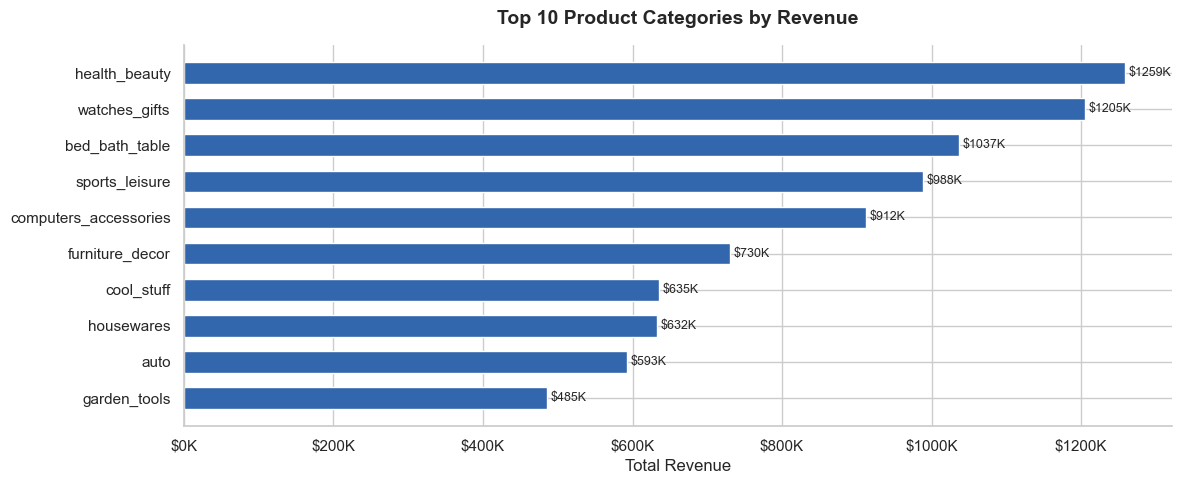

Chart saved to outputs folder.


In [8]:
conn = sqlite3.connect(DB_PATH)

df_revenue = pd.read_sql("""
    SELECT
        c.product_category_name_english AS category,
        ROUND(SUM(i.price), 2)          AS total_revenue
    FROM order_items i
    JOIN products   p ON i.product_id = p.product_id
    JOIN categories c ON p.product_category_name = c.product_category_name
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)

conn.close()

fig, ax = plt.subplots()
bars = ax.barh(df_revenue['category'][::-1],
               df_revenue['total_revenue'][::-1],
               color='#3266ad', height=0.6)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
ax.set_xlabel('Total Revenue')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold', pad=15)

for bar, val in zip(bars, df_revenue['total_revenue'][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/chart1_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs folder.")

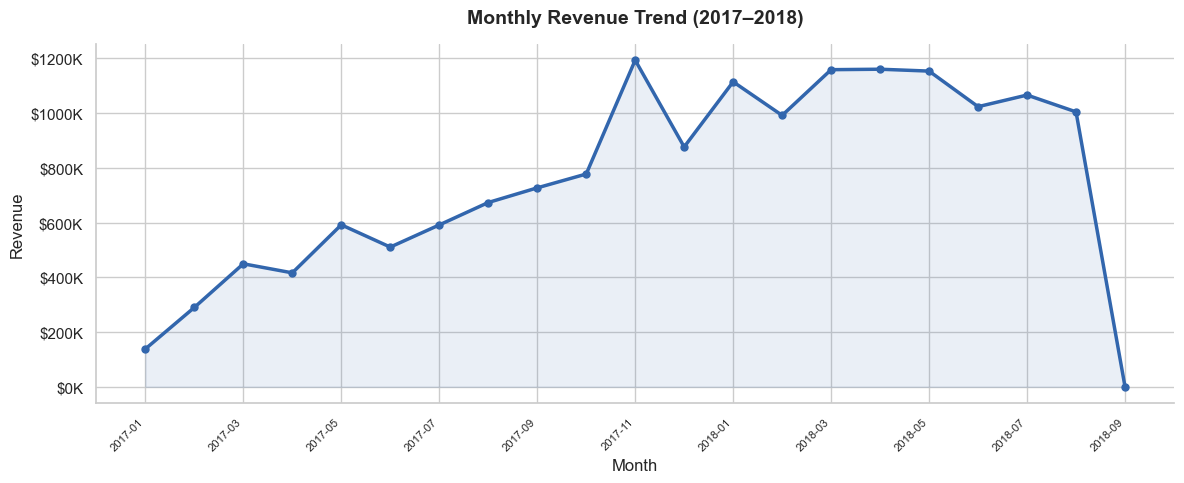

Chart saved.


In [9]:
conn = sqlite3.connect(DB_PATH)

df_monthly = pd.read_sql("""
    SELECT
        STRFTIME('%Y-%m', order_purchase_timestamp) AS month,
        ROUND(SUM(payment_value), 2)                AS revenue
    FROM orders o
    JOIN payments p ON o.order_id = p.order_id
    WHERE order_purchase_timestamp IS NOT NULL
    AND STRFTIME('%Y', order_purchase_timestamp) IN ('2017', '2018')
    GROUP BY month
    ORDER BY month
""", conn)

conn.close()

fig, ax = plt.subplots()
ax.plot(df_monthly['month'], df_monthly['revenue'],
        color='#3266ad', linewidth=2.5, marker='o', markersize=5)

ax.fill_between(df_monthly['month'], df_monthly['revenue'],
                alpha=0.1, color='#3266ad')

ax.set_xticks(range(0, len(df_monthly), 2))
ax.set_xticklabels(df_monthly['month'][::2], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))

ax.set_title('Monthly Revenue Trend (2017–2018)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')

plt.tight_layout()
plt.savefig('../outputs/chart2_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

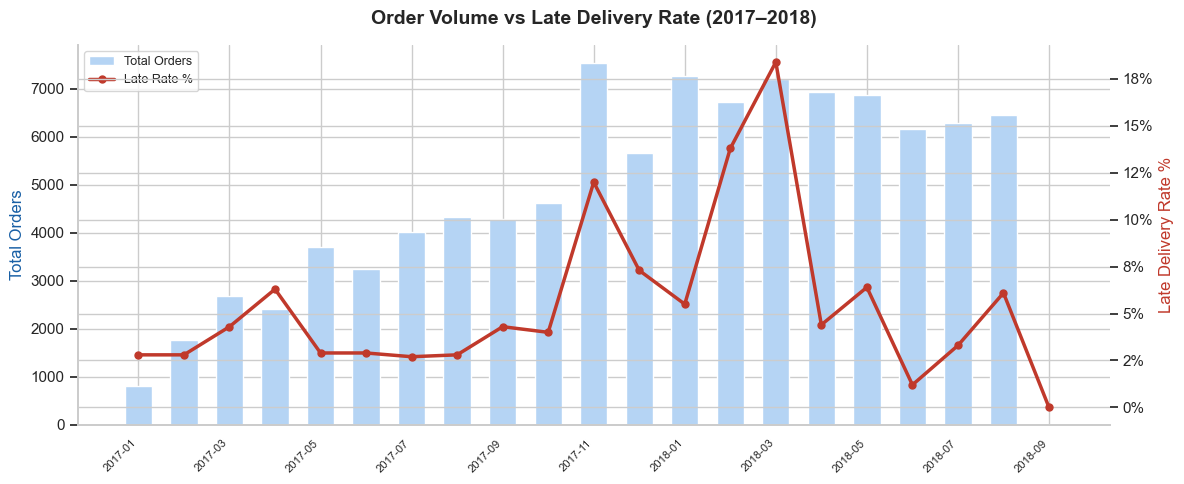

Chart saved.


In [10]:
conn = sqlite3.connect(DB_PATH)

df_delays = pd.read_sql("""
    SELECT
        STRFTIME('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(order_id)                             AS total_orders,
        SUM(is_late)                                AS late_orders,
        ROUND(AVG(is_late) * 100, 1)               AS late_rate_pct
    FROM orders
    WHERE order_purchase_timestamp IS NOT NULL
    AND STRFTIME('%Y', order_purchase_timestamp) IN ('2017', '2018')
    GROUP BY month
    ORDER BY month
""", conn)

conn.close()

fig, ax1 = plt.subplots()

ax1.bar(df_delays['month'], df_delays['total_orders'],
        color='#b5d4f4', label='Total Orders', width=0.6)

ax2 = ax1.twinx()
ax2.plot(df_delays['month'], df_delays['late_rate_pct'],
         color='#C0392B', linewidth=2.5, marker='o',
         markersize=5, label='Late Rate %')

ax1.set_xticks(range(0, len(df_delays), 2))
ax1.set_xticklabels(df_delays['month'][::2], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Total Orders', color='#185FA5')
ax2.set_ylabel('Late Delivery Rate %', color='#C0392B')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax1.set_title('Order Volume vs Late Delivery Rate (2017–2018)',
              fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/chart3_late_deliveries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

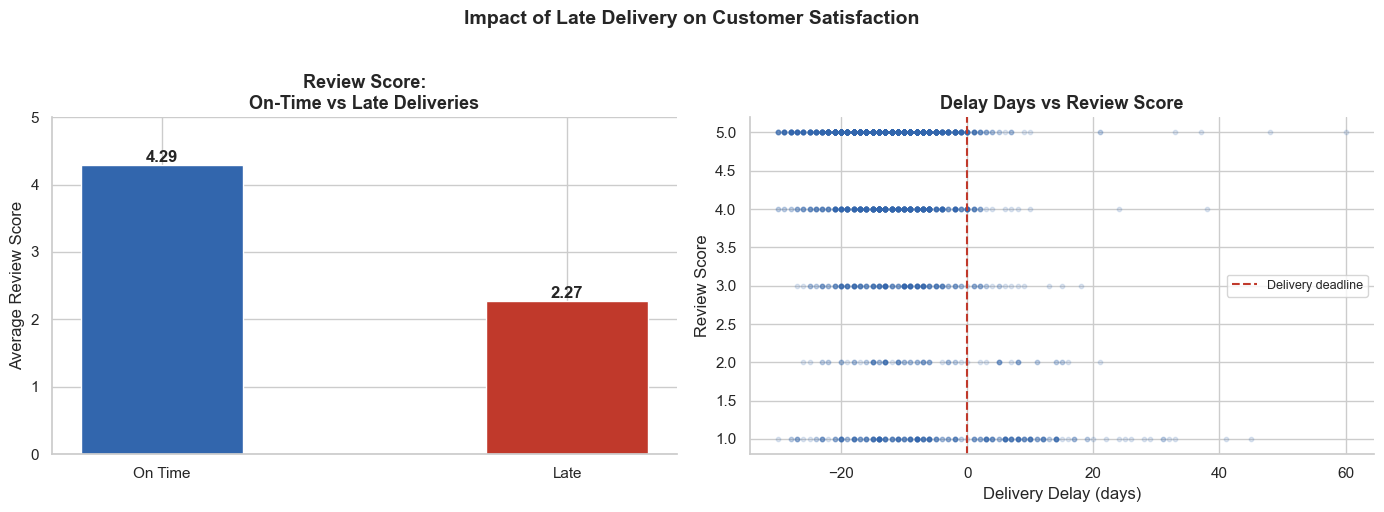

Chart saved.


In [11]:
conn = sqlite3.connect(DB_PATH)

df_review_late = pd.read_sql("""
    SELECT
        o.is_late,
        ROUND(AVG(r.review_score), 2) AS avg_review,
        COUNT(r.review_id)            AS total_reviews
    FROM orders  o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_delivered_customer_date IS NOT NULL
    GROUP BY o.is_late
""", conn)

df_corr = pd.read_sql("""
    SELECT
        o.delivery_delay_days,
        r.review_score
    FROM orders  o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.delivery_delay_days IS NOT NULL
    AND o.delivery_delay_days BETWEEN -30 AND 60
""", conn)

conn.close()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

labels = ['On Time', 'Late']
scores = df_review_late['avg_review'].values
colors = ['#3266ad', '#C0392B']
bars   = ax1.bar(labels, scores, color=colors, width=0.4)
ax1.set_ylim(0, 5)
ax1.set_ylabel('Average Review Score')
ax1.set_title('Review Score:\nOn-Time vs Late Deliveries',
              fontsize=13, fontweight='bold')
for bar, val in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val}', ha='center', fontsize=12, fontweight='bold')

sample = df_corr.sample(n=min(3000, len(df_corr)), random_state=42)
ax2.scatter(sample['delivery_delay_days'], sample['review_score'],
            alpha=0.15, color='#3266ad', s=10)
ax2.axvline(x=0, color='#C0392B', linewidth=1.5, linestyle='--', label='Delivery deadline')
ax2.set_xlabel('Delivery Delay (days)')
ax2.set_ylabel('Review Score')
ax2.set_title('Delay Days vs Review Score',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Impact of Late Delivery on Customer Satisfaction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/chart4_reviews_vs_delays.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")